In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt

train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")

train_df.head()

,timestamp,encounter_id,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,label
0,2025-01-01 19:00:00,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,88.0,104.0,74.0,18.0,95.0,0
1,2025-01-01 19:00:05,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,88.0,100.0,72.0,18.0,95.0,0
2,2025-01-01 19:00:10,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,86.0,96.0,70.0,17.0,94.0,0
3,2025-01-01 19:00:15,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,89.0,98.0,70.0,18.0,94.0,0
4,2025-01-01 19:00:20,b317e7ee-8af7-3e9c-3e0f-646395b8c81a_0,91.0,98.0,70.0,NaN,94.0,0


In [2]:
# GET RID OF NULL VALS AND TRANSFORM DATA (NORMALISE)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
cols = ["heart_rate", "systolic_bp", "diastolic_bp", "respiratory_rate", "oxygen_saturation"]
train_df[cols] = sc.fit_transform(train_df[cols])

train_df[cols] = train_df.groupby("encounter_id")[cols].transform(lambda x:x.fillna(x.median()))
train_df.isnull().sum()

timestamp            0
encounter_id         0
heart_rate           0
systolic_bp          0
diastolic_bp         0
respiratory_rate     0
oxygen_saturation    0
label                0
dtype: int64

In [3]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 3, random_state=1, class_weight='balanced')


In [4]:
# CONVERTING TIMESTAMPS TO ACTUAL DATE TIME 
train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

# SORT VALS TO OPTIMISE GROUP BY
train_df = train_df.sort_values(["encounter_id", "timestamp"])
test_df = test_df.sort_values(["encounter_id", "timestamp"])

In [5]:
# ADD ROLLING MEAN/STD FOR EACH COLUMN
window_1m = 12
window_5m = 60

for col in cols:
    train_df[f"{col}_mean_1m"] = (
        train_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).mean())
    )
    train_df[f"{col}_std_1m"] = (
        train_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).std())
    )
    train_df[f"{col}_mean_5m"] = (
        train_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_5m, min_periods=1).mean())
    )

In [6]:
# FIT RF MODEL ON NEW UPDATED TRAIN DATA 
new_df = train_df.drop(columns=["encounter_id", "timestamp", "label"])
X_train, y_train= new_df, train_df["label"]
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=3, random_state=1)

In [7]:
# DO THE SAME THING TO TEST DATA (ADD COLUMNS FOR ROLLING AVG)
for col in cols:
    test_df[f"{col}_mean_1m"] = (
        test_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).mean())
    )
    test_df[f"{col}_std_1m"] = (
        test_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).std())
    )
    test_df[f"{col}_mean_5m"] = (
        test_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_5m, min_periods=1).mean())
    )


In [8]:
new_test_df = test_df.drop(columns=["timestamp", "encounter_id", "label"])
X_test, y_test = new_test_df, test_df["label"]
rf.score(X_test, y_test)

0.7190988835725678

In [9]:
# K MEANS STUFF
# n_df = df[cols]
# n_df

# kmeans = KMeans(n_clusters=4, n_init = 10, random_state=67)
# kmeans.fit(n_df)

# clusters = kmeans.predict(n_df)
# print(clusters[:300])


In [10]:
from sklearn.metrics import confusion_matrix
# Make predictions using svm model for all X_test entries
y_pred = rf.predict(X_test)
# Generate a confusion matrix using actual (y_test) and predicted (svm_y_predicted)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[322592   6431   7328      3]
 [ 71806   1399   1543      0]
 [ 28584    541    634      0]
 [  7996   2090    488      5]]


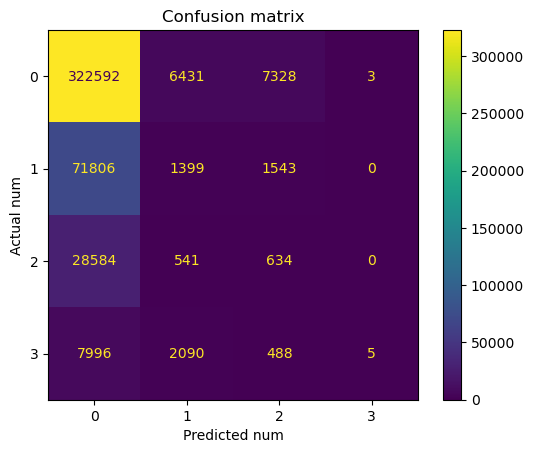

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
# Create display object with the correct display labels (grade class letter)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)

# Make the confusion matrix into a pyplot
cm_display.plot()
plt.title("Confusion matrix")
plt.xlabel("Predicted num")
plt.ylabel("Actual num")
plt.show()

In [13]:
submit_df = pd.read_csv("holdout_data.csv")

# normalise data
submit_df[cols] = sc.fit_transform(submit_df[cols])

# add the extra cols
for col in cols:
    submit_df[f"{col}_mean_1m"] = (
        submit_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).mean())
    )
    submit_df[f"{col}_std_1m"] = (
        submit_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_1m, min_periods=1).std())
    )
    submit_df[f"{col}_mean_5m"] = (
        submit_df.groupby("encounter_id")[col].transform(lambda x: x.rolling(window_5m, min_periods=1).mean())
    )

submit_X = submit_df.drop(["encounter_id", "timestamp"], axis=1)

In [15]:
submit_preds = rf.predict(submit_X)
submit_preds

array([0, 0, 0, ..., 1, 1, 1])

In [24]:
predictions_df = pd.DataFrame({
    'ID': range(1, len(submit_preds) + 1),
    'predicted_label': submit_preds
})
predictions_df.head()

,ID,predicted_label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [25]:
predictions_df.to_csv("predictions.csv", index=False)